In [1]:
# notebooks/03_monitor_training.ipynb

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


[INFO] Loaded 50 epochs of training data.
Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


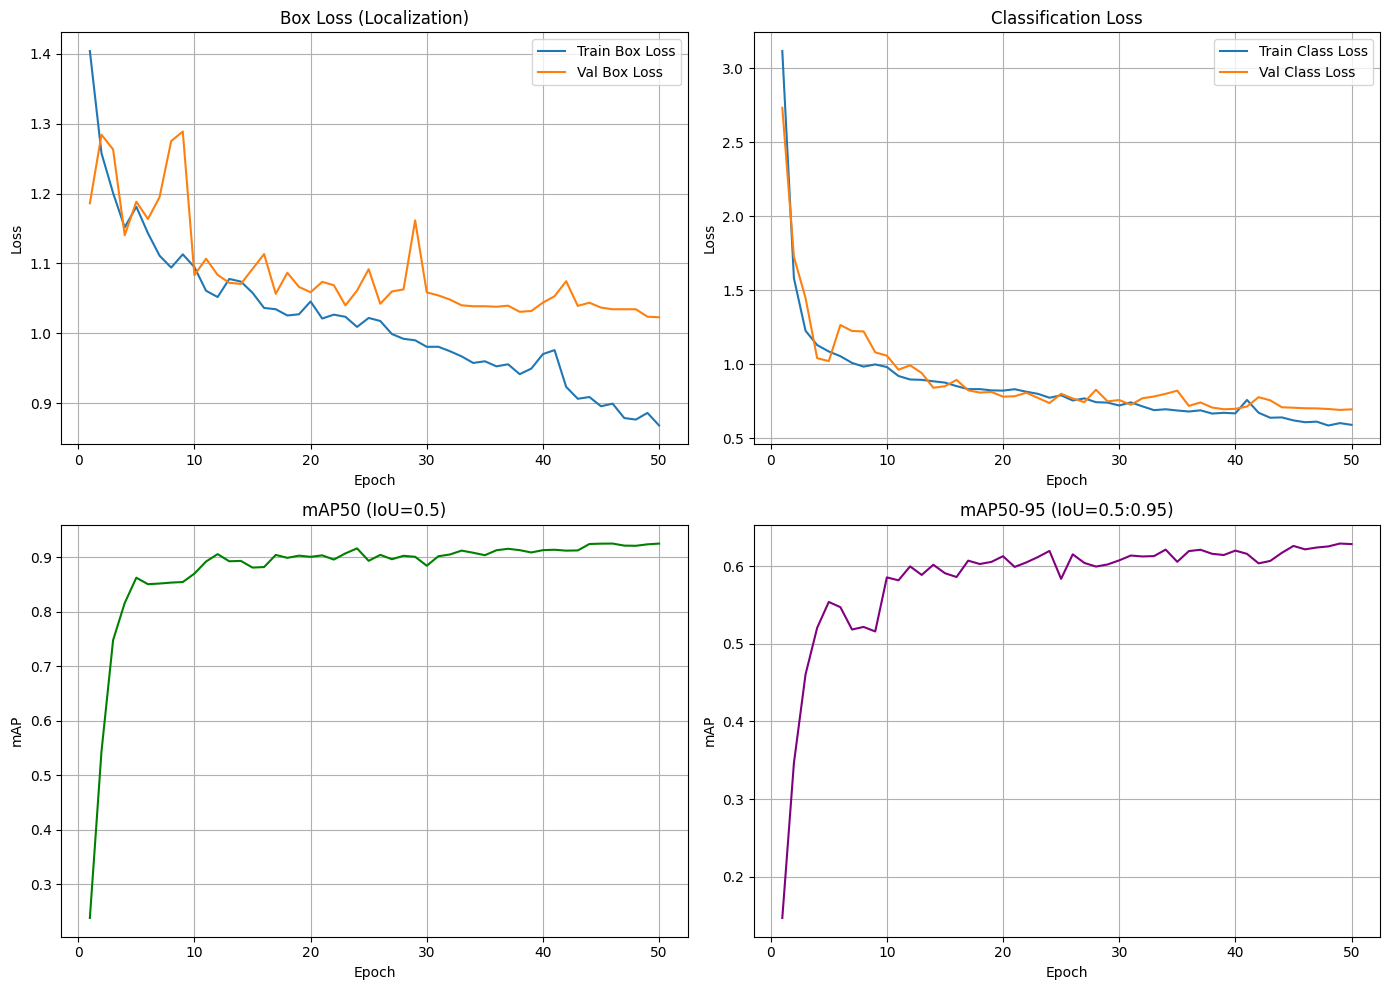


[SUMMARY] Best mAP50: 0.9250 at epoch 46
[SUMMARY] Best mAP50-95: 0.6289


In [ ]:

# Path to the training results CSV generated by YOLO

results_csv = Path("../runs/detect/blood_detection/detection_run/results.csv")

if not results_csv.exists():
    print("[WARNING] results.csv not found. Start training first or check the path.")
    print(f"Expected: {results_csv.resolve()}")
else:
    # Load the CSV
    df = pd.read_csv(results_csv)
    
    print(f"[INFO] Loaded {len(df)} epochs of training data.")
    print(df.columns)
     # Plot training and validation losses
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Box Loss (Localization)
    axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
    axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
    axes[0, 0].set_title('Box Loss (Localization)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Classification Loss
    axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss')
    axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss')
    axes[0, 1].set_title('Classification Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # mAP50 (Main metric for detection)
    axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green')
    axes[1, 0].set_title('mAP50 (IoU=0.5)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('mAP')
    axes[1, 0].grid(True)
    
    # mAP50-95 (Stricter metric)
    axes[1, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='purple')
    axes[1, 1].set_title('mAP50-95 (IoU=0.5:0.95)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('mAP')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    # Print best metrics
    best_epoch = df['metrics/mAP50(B)'].idxmax()
    print(f"\n[SUMMARY] Best mAP50: {df.loc[best_epoch, 'metrics/mAP50(B)']:.4f} at epoch {df.loc[best_epoch, 'epoch']}")
    print(f"[SUMMARY] Best mAP50-95: {df['metrics/mAP50-95(B)'].max():.4f}")